Matplotlib is building the font cache; this may take a moment.


🚀 MEMULAI BENCHMARK OTOMATIS...

⏳ Menembak Monolitik (Kecil)...
✅ Selesai! Req/Sec: 1122.41 | Latency: 21.8 ms
⏳ Menembak Polyglot (Kecil)...
✅ Selesai! Req/Sec: 1004.9 | Latency: 24.39 ms
⏳ Menembak Monolitik (Menengah)...
✅ Selesai! Req/Sec: 4.91 | Latency: 3946.29 ms
⏳ Menembak Polyglot (Menengah)...
✅ Selesai! Req/Sec: 1410.9 | Latency: 17.22 ms
⏳ Menembak Monolitik (Besar)...
✅ Selesai! Req/Sec: 4.2 | Latency: 4124.72 ms
⏳ Menembak Polyglot (Besar)...
✅ Selesai! Req/Sec: 1462.1 | Latency: 16.61 ms


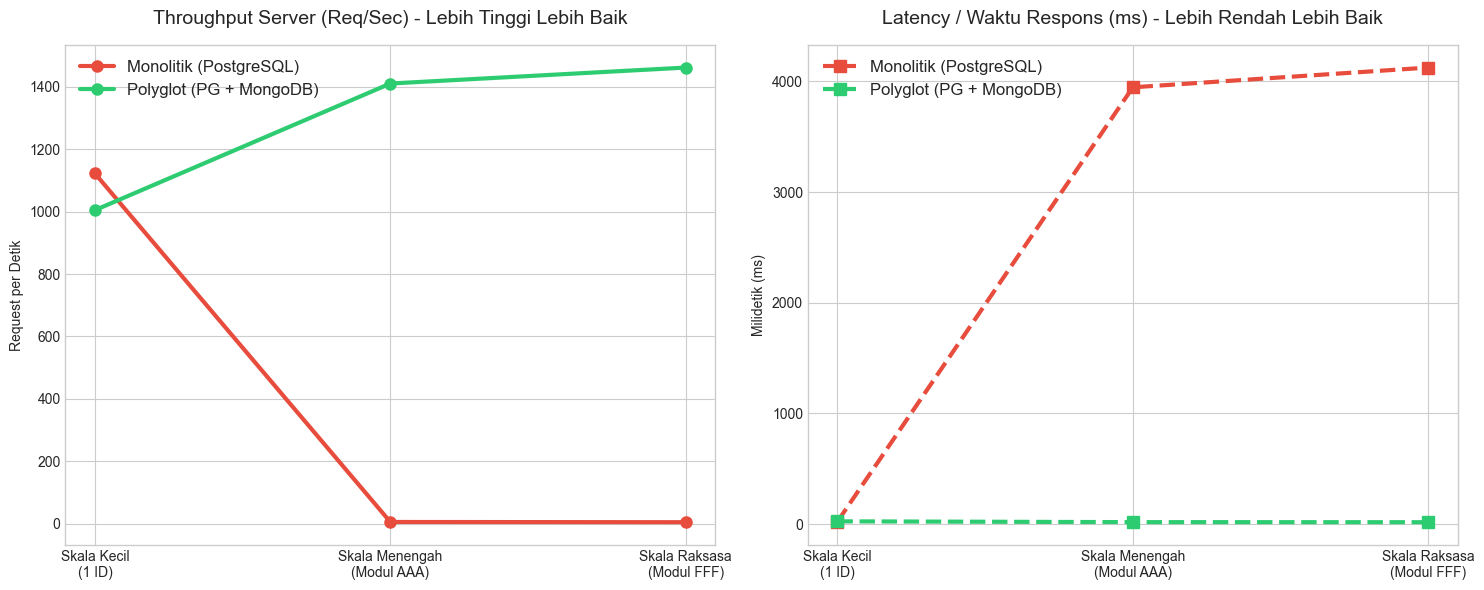

In [1]:
import subprocess
import json
import matplotlib.pyplot as plt
import pandas as pd

# Fungsi untuk memanggil Autocannon Node.js dari dalam Python
def run_autocannon(name, url, connections=25, duration=10):
    print(f"⏳ Menembak {name}...")
    # Kita tambahkan flag --json agar outputnya bisa dibaca Python
    cmd = f"npx autocannon -c {connections} -d {duration} --json {url}"
    
    # Jalankan perintah di terminal secara background
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    
    try:
        data = json.loads(result.stdout)
        req_sec = data['requests']['average']
        latency = data['latency']['average']
        print(f"✅ Selesai! Req/Sec: {req_sec} | Latency: {latency} ms")
        return req_sec, latency
    except Exception as e:
        print(f"❌ Error pada {name}: {e}")
        return 0, 0

print("🚀 MEMULAI BENCHMARK OTOMATIS...\n")

# 1. Eksekusi Skenario
scenarios = ["Skala Kecil\n(1 ID)", "Skala Menengah\n(Modul AAA)", "Skala Raksasa\n(Modul FFF)"]

mono_req, mono_lat = [], []
poly_req, poly_lat = [], []

# Skala Kecil
r, l = run_autocannon('Monolitik (Kecil)', 'http://localhost:3000/api/baseline/11391')
mono_req.append(r); mono_lat.append(l)
r, l = run_autocannon('Polyglot (Kecil)', 'http://localhost:3000/api/polyglot/11391')
poly_req.append(r); poly_lat.append(l)

# Skala Menengah
r, l = run_autocannon('Monolitik (Menengah)', 'http://localhost:3000/api/baseline-heavy/AAA/2013J')
mono_req.append(r); mono_lat.append(l)
r, l = run_autocannon('Polyglot (Menengah)', 'http://localhost:3000/api/polyglot-heavy/AAA/2013J')
poly_req.append(r); poly_lat.append(l)

# Skala Raksasa
r, l = run_autocannon('Monolitik (Besar)', 'http://localhost:3000/api/baseline-heavy/FFF/2013J')
mono_req.append(r); mono_lat.append(l)
r, l = run_autocannon('Polyglot (Besar)', 'http://localhost:3000/api/polyglot-heavy/FFF/2013J')
poly_req.append(r); poly_lat.append(l)

# 2. Visualisasi dengan Matplotlib (Line Chart)
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Grafik Throughput (Req/Sec)
ax1.plot(scenarios, mono_req, marker='o', markersize=8, linewidth=3, label='Monolitik (PostgreSQL)', color='#e74c3c')
ax1.plot(scenarios, poly_req, marker='o', markersize=8, linewidth=3, label='Polyglot (PG + MongoDB)', color='#2ecc71')
ax1.set_title('Throughput Server (Req/Sec) - Lebih Tinggi Lebih Baik', fontsize=14, pad=15)
ax1.set_ylabel('Request per Detik')
ax1.legend(fontsize=12)

# Grafik Latency (ms)
ax2.plot(scenarios, mono_lat, marker='s', markersize=8, linewidth=3, linestyle='--', label='Monolitik (PostgreSQL)', color='#e74c3c')
ax2.plot(scenarios, poly_lat, marker='s', markersize=8, linewidth=3, linestyle='--', label='Polyglot (PG + MongoDB)', color='#2ecc71')
ax2.set_title('Latency / Waktu Respons (ms) - Lebih Rendah Lebih Baik', fontsize=14, pad=15)
ax2.set_ylabel('Milidetik (ms)')
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()